# Projections and Components

## Purpose

Understand projection as the part of one vector that lies in the direction of another, and use it to split a vector into parallel and perpendicular components.

This notebook builds on the dot product and cosine similarity notebook.

The goal is not to memorise a formula in isolation. The goal is to connect the formula to a visual idea:

> projection tells us where one vector lands on the direction of another vector.

## Helpers

These helpers keep the plotting code out of the main learning examples.

The diagrams in this notebook use 2D vectors because they are easy to visualise, but the projection ideas apply in higher dimensions too.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_vector_plot(title=None, xlim=(-1, 6), ylim=(-1, 5), figsize=(5, 4.5)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    if title:
        ax.set_title(title)

    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.006,
    alpha=1.0,
    linestyle="-",
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
        alpha=alpha,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_dashed_line(ax, start, end):
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        linestyle="--",
        linewidth=1,
    )


def projection_of(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    denominator = b @ b

    if denominator == 0:
        raise ValueError("Cannot project onto the zero vector.")

    return ((a @ b) / denominator) * b


def perpendicular_component_of(a, b):
    a = np.array(a, dtype=float)
    return a - projection_of(a, b)


def print_vector(name, vector):
    vector = np.array(vector, dtype=float)
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")

## Recap: dot product and cosine similarity

The dot product measures how aligned two vectors are.

For two non-zero vectors $a$ and $b$:

$$
a \cdot b = \|a\| \|b\| \cos(\theta)
$$

So the dot product combines length and direction.

Cosine similarity removes the effect of length:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\| \|b\|}
$$

Projection builds directly on this idea.

In [3]:
axis_a = np.array([4, 3])
axis_b = np.array([5, 0])

dot_ab = axis_a @ axis_b
norm_a = np.linalg.norm(axis_a)
norm_b = np.linalg.norm(axis_b)
cosine_similarity = dot_ab / (norm_a * norm_b)

print_vector("axis_a", axis_a)
print_vector("axis_b", axis_b)
print(f"axis_a · axis_b = {dot_ab:.2f}")
print(f"||axis_a|| = {norm_a:.2f}")
print(f"||axis_b|| = {norm_b:.2f}")
print(f"cosine similarity = {cosine_similarity:.2f}")

axis_a = [ 4.00,  3.00]
axis_b = [ 5.00,  0.00]
axis_a · axis_b = 20.00
||axis_a|| = 5.00
||axis_b|| = 5.00
cosine similarity = 0.80


## What does projection mean?

A projection answers the question:

> How much of one vector lies in the direction of another vector?

In this notebook, I will use the following language:

- the **object vector** is the vector being projected
- the **target vector** is the vector being projected onto

Projection can mean two closely related things.

The **scalar projection** is a signed number: how far the object vector reaches in the target direction.

The **vector projection** is a vector: the actual target-aligned component of the object vector.

When people simply say “the projection of $a$ onto $b$”, they often mean the vector projection:

$$
\operatorname{proj}_{b}(a)
$$

This means:

> the projection of object vector $a$ onto target vector $b$

The vector projection keeps only the part of the object vector that lies along the target direction.

The scalar projection records the signed length of that part.

## Axis-aligned example: seeing the landing point

Start with an intentionally friendly example:

$$
a =
\begin{bmatrix}
4 \\
3
\end{bmatrix}
\qquad
b =
\begin{bmatrix}
5 \\
0
\end{bmatrix}
$$

The target vector $b$ points along the x-axis.

That makes the projection easy to see: if $a$ is dropped perpendicularly onto the line through $b$, it lands at $[4, 0]$.

So in this example, the vector projection should be:

$$
\operatorname{proj}_{b}(a) =
\begin{bmatrix}
4 \\
0
\end{bmatrix}
$$

The leftover perpendicular part should be:

$$
a - \operatorname{proj}_{b}(a) =
\begin{bmatrix}
0 \\
3
\end{bmatrix}
$$

In [4]:
axis_projection = projection_of(axis_a, axis_b)
axis_perpendicular = perpendicular_component_of(axis_a, axis_b)

print_vector("object vector axis_a", axis_a)
print_vector("target vector axis_b", axis_b)
print_vector("projection of axis_a onto axis_b", axis_projection)
print_vector("perpendicular leftover", axis_perpendicular)

object vector axis_a = [ 4.00,  3.00]
target vector axis_b = [ 5.00,  0.00]
projection of axis_a onto axis_b = [ 4.00,  0.00]
perpendicular leftover = [ 0.00,  3.00]


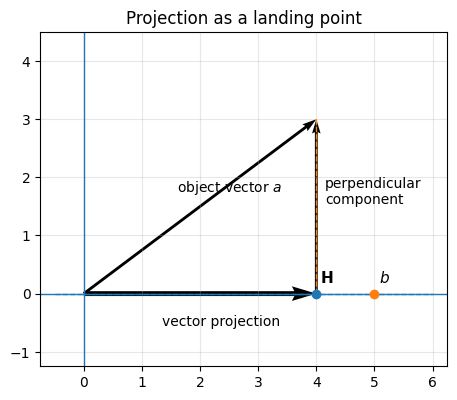

In [5]:
fig, ax = setup_vector_plot(
    title="Projection as a landing point",
    xlim=(-0.75, 6.25),
    ylim=(-1.25, 4.5),
    figsize=(5.25, 4.5),
)

# Target direction / base line.
ax.plot([-0.5, 6], [0, 0], linestyle="--", linewidth=1)

# Main vectors/components.
draw_vector(ax, axis_a, width=0.007)
draw_vector(ax, axis_projection, width=0.012)
draw_vector(ax, axis_perpendicular, origin=axis_projection, width=0.007)

# Perpendicular guide.
draw_dashed_line(ax, axis_a, axis_projection)

# Key points.
ax.scatter(axis_projection[0], axis_projection[1], zorder=4)
ax.scatter(axis_b[0], axis_b[1], zorder=4)

# Manual labels.
ax.text(1.6, 1.75, "object vector $a$", fontsize=10)
ax.text(1.35, -0.55, "vector projection", fontsize=10)
ax.text(4.15, 1.55, "perpendicular\ncomponent", fontsize=10)
ax.text(4.08, 0.18, "H", fontsize=11, fontweight="bold")
ax.text(5.08, 0.18, "$b$", fontsize=11, fontweight="bold")

plt.show()

Here, $H$ is the landing point.

The vector from the origin to $H$ is the vector projection of $a$ onto $b$.

The vertical part from $H$ to the end of $a$ is the perpendicular component.

In this axis-aligned example, the target line is just the x-axis, so the projection is easy to see:

$$
\operatorname{proj}_b(a) = [4, 0]
$$

It shows the main decomposition:

$$
a = \operatorname{proj}_{b}(a) + \left(a - \operatorname{proj}_{b}(a)\right)
$$

In words:

> the object vector equals its target-aligned part plus its perpendicular leftover.

## Scalar projection

The scalar projection tells us the signed length of the part of $a$ that lies in the direction of $b$.

It is calculated as:

$$
\operatorname{scalarproj}_{b}(a) =
\frac{a \cdot b}{\|b\|}
$$

Equivalently, if $\hat{b}$ is the unit vector in the direction of $b$:

$$
\operatorname{scalarproj}_{b}(a) =
a \cdot \hat{b}
$$

This gives a number, not a vector.

In [6]:
axis_unit_b = axis_b / np.linalg.norm(axis_b)
axis_scalar_projection = axis_a @ axis_unit_b

print_vector("unit vector in direction of axis_b", axis_unit_b)
print(f"scalar projection of axis_a onto axis_b = {axis_scalar_projection:.2f}")

unit vector in direction of axis_b = [ 1.00,  0.00]
scalar projection of axis_a onto axis_b = 4.00


The scalar projection is $4$.

That makes sense visually. The object vector $a = [4, 3]$ moves 4 units in the x direction, and the target vector $b = [5, 0]$ points exactly along the x-axis.

So the signed length of the part of $a$ that lies in the direction of $b$ is 4.

## Vector projection

The vector projection turns the scalar projection back into a vector.

We take the signed length along $b$, then multiply by the unit vector in the direction of $b$:

$$
\operatorname{proj}_{b}(a) =
(a \cdot \hat{b})\hat{b}
$$

Another common form is:

$$
\operatorname{proj}_{b}(a) =
\frac{a \cdot b}{b \cdot b}b
$$

These are equivalent.

The first form says:

> find the signed length along the target direction, then point that length in the target direction.

The second form avoids explicitly naming the unit vector.

In [7]:
axis_projection_using_unit_b = (axis_a @ axis_unit_b) * axis_unit_b
axis_projection_using_b = ((axis_a @ axis_b) / (axis_b @ axis_b)) * axis_b

print_vector("using unit_b", axis_projection_using_unit_b)
print_vector("using b directly", axis_projection_using_b)

using unit_b = [ 4.00,  0.00]
using b directly = [ 4.00,  0.00]


Both calculations give the same result:

$$
\operatorname{proj}_{b}(a) = [4, 0]
$$

In this example:

- scalar projection = $4$
- vector projection = $[4, 0]$

The scalar version is just the signed length.

The vector version includes the direction as well.

## Parallel and perpendicular components

Projection lets us split one vector into two parts:

$$
a = a_{\parallel} + a_{\perp}
$$

Where:

$$
a_{\parallel} = \operatorname{proj}_{b}(a)
$$

and:

$$
a_{\perp} = a - \operatorname{proj}_{b}(a)
$$

The parallel component lies along the target direction.

The perpendicular component is at right angles to the target direction.

In [8]:
axis_parallel = projection_of(axis_a, axis_b)
axis_perpendicular = perpendicular_component_of(axis_a, axis_b)

print_vector("axis_a", axis_a)
print_vector("parallel component", axis_parallel)
print_vector("perpendicular component", axis_perpendicular)
print_vector("parallel + perpendicular", axis_parallel + axis_perpendicular)

axis_a = [ 4.00,  3.00]
parallel component = [ 4.00,  0.00]
perpendicular component = [ 0.00,  3.00]
parallel + perpendicular = [ 4.00,  3.00]


The object vector has been split into:

$$
[4, 3] = [4, 0] + [0, 3]
$$

That is visually obvious in this axis-aligned example, but the same logic works for any target direction.

## Checking the decomposition

If the perpendicular component is genuinely perpendicular to the target vector, their dot product should be zero.

This is because perpendicular vectors have cosine similarity zero, and therefore dot product zero.

In [9]:
axis_dot_perpendicular_with_b = axis_perpendicular @ axis_b

print_vector("perpendicular component", axis_perpendicular)
print_vector("target vector axis_b", axis_b)
print(f"perpendicular · axis_b = {axis_dot_perpendicular_with_b:.2f}")

perpendicular component = [ 0.00,  3.00]
target vector axis_b = [ 5.00,  0.00]
perpendicular · axis_b = 0.00


The result is zero.

That confirms that the leftover component is perpendicular to the target direction.

## The same idea without an axis-aligned target

The first example used a target vector pointing along the x-axis.

That made the projection easy to see, because the target direction was already one of the normal coordinate axes.

But projection does not depend on the target vector being horizontal or vertical.

The same idea works for any target direction.

In [10]:
general_a = np.array([3, 4])
general_b = np.array([5, 1.2])

general_unit_b = general_b / np.linalg.norm(general_b)
general_scalar_projection = general_a @ general_unit_b
general_projection = projection_of(general_a, general_b)
general_perpendicular = perpendicular_component_of(general_a, general_b)

print_vector("general_a", general_a)
print_vector("general_b", general_b)
print(f"scalar projection of general_a onto general_b = {general_scalar_projection:.2f}")
print_vector("vector projection", general_projection)
print_vector("perpendicular leftover", general_perpendicular)
print_vector("reconstructed vector", general_projection + general_perpendicular)

general_a = [ 3.00,  4.00]
general_b = [ 5.00,  1.20]
scalar projection of general_a onto general_b = 3.85
vector projection = [ 3.74,  0.90]
perpendicular leftover = [-0.74,  3.10]
reconstructed vector = [ 3.00,  4.00]


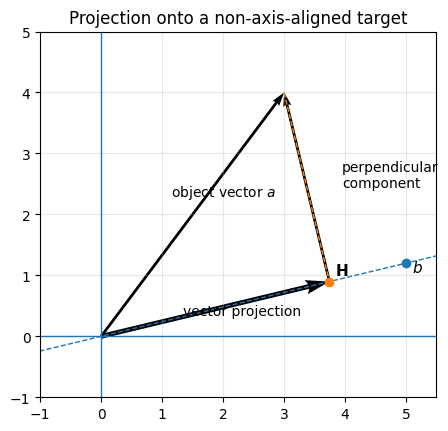

In [11]:
fig, ax = setup_vector_plot(
    title="Projection onto a non-axis-aligned target",
    xlim=(-1, 5.5),
    ylim=(-1, 5),
    figsize=(5.25, 4.75),
)

# Line through general_b, extended beyond the vector itself.
line_scale = np.linspace(-0.25, 1.35, 100)
line_points = np.outer(line_scale, general_b)
ax.plot(line_points[:, 0], line_points[:, 1], linestyle="--", linewidth=1)

# Main visual pieces.
draw_vector(ax, general_a, width=0.007)
draw_vector(ax, general_projection, width=0.012)
draw_vector(ax, general_perpendicular, origin=general_projection, width=0.007)

# Perpendicular guide.
draw_dashed_line(ax, general_a, general_projection)

# Key points.
ax.scatter(general_b[0], general_b[1], zorder=4)
ax.scatter(general_projection[0], general_projection[1], zorder=4)

# Manual labels.
ax.text(1.15, 2.3, "object vector $a$", fontsize=10)
ax.text(1.35, 0.35, "vector projection", fontsize=10)
ax.text(3.95, 2.45, "perpendicular\ncomponent", fontsize=10)

ax.text(general_b[0] + 0.1, general_b[1] - 0.15, "$b$", fontsize=11, fontweight="bold")
ax.text(
    general_projection[0] + 0.1,
    general_projection[1] + 0.1,
    "H",
    fontsize=11,
    fontweight="bold",
)

plt.show()

This example is less visually convenient, but it is the real point of the method.

The projection still lands on the line through the target vector.

The perpendicular leftover is still at right angles to the target vector.

And the object vector is still reconstructed by adding the two components:

$$
a = a_{\parallel} + a_{\perp}
$$

In [12]:
general_dot_perpendicular_with_b = general_perpendicular @ general_b

print_vector("perpendicular component", general_perpendicular)
print_vector("target vector general_b", general_b)
print(f"perpendicular · general_b = {general_dot_perpendicular_with_b:.10f}")

perpendicular component = [-0.74,  3.10]
target vector general_b = [ 5.00,  1.20]
perpendicular · general_b = -0.0000000000


The result is effectively zero.

Small floating-point rounding errors can appear in decimal output, but the geometric idea is the same:

> the leftover component is perpendicular to the target direction.

## Projection as a rotated-axis idea

A useful mental model is to imagine temporarily treating the target vector as the main axis.

If the target vector $b$ were the main axis, the object vector $a$ would have:

- one component along $b$
- one component sideways from $b$

The projection is the “along $b$” part, expressed back in the original coordinate system.

This is only an intuition. We do not actually need to rotate the plane to calculate the projection.

## Projection and the triangle picture

There is also a useful triangle picture.

Imagine the triangle with these vertices:

- $O$: the origin
- $A$: the end of the object vector $a$
- $B$: the end of the target vector $b$

The vector $b$ forms the base direction.

The object vector $a$ forms another side of the triangle.

The projection is **not** the height of the triangle.

Instead, it is the vector from the origin to the point where the perpendicular from $A$ intersects the line through $b$.

So if $H$ is the foot of that perpendicular:

$$
\operatorname{proj}_{b}(a) = \overrightarrow{OH}
$$

The height direction is the leftover perpendicular part:

$$
a - \operatorname{proj}_{b}(a) = \overrightarrow{HA}
$$

In the axis-aligned example, this is especially clear:

$$
a = [4, 3]
$$

$$
\operatorname{proj}_{b}(a) = [4, 0]
$$

$$
a - \operatorname{proj}_{b}(a) = [0, 3]
$$

The projection tells us where the perpendicular from $a$ lands on the target/base line.

The perpendicular component gives the height direction.

## Height of the triangle

When using $b$ as the base direction of the triangle, the height is the length of the perpendicular component:

$$
\text{height} = \left\|a - \operatorname{proj}_{b}(a)\right\|
$$

For the axis-aligned example, the perpendicular component is $[0, 3]$, so the height is 3.

In [13]:
axis_height = np.linalg.norm(axis_perpendicular)

print(f"height = {axis_height:.2f}")

height = 3.00


The area of the triangle formed by $a$ and $b$ can then be calculated using the usual triangle area formula:

$$
\text{area} = \frac{1}{2} \times \text{base} \times \text{height}
$$

Here, the base length is $\|b\|$.

In [14]:
axis_base = np.linalg.norm(axis_b)
axis_area = 0.5 * axis_base * axis_height

print(f"base = {axis_base:.2f}")
print(f"height = {axis_height:.2f}")
print(f"area = {axis_area:.2f}")

base = 5.00
height = 3.00
area = 7.50


## Why this matters for least squares

Projection is not just a geometry trick.

In least squares problems, we often cannot hit a target exactly. Instead, we find the closest reachable approximation.

That idea can be understood using projection:

- the reachable approximation is the projected part
- the error or residual is the perpendicular leftover

In this notebook’s language:

$$
\text{object vector} =
\text{projection} +
\text{perpendicular leftover}
$$

In least squares language, this becomes something like:

$$
\text{target} =
\text{best approximation} +
\text{residual}
$$

The residual being perpendicular is the key geometric idea behind least squares.

## Edge case: projecting onto the zero vector

Projection onto the zero vector is undefined.

The zero vector has no direction, and the projection formula divides by $b \cdot b$:

$$
\operatorname{proj}_{b}(a) =
\frac{a \cdot b}{b \cdot b}b
$$

If $b = [0, 0]$, then $b \cdot b = 0$, so the calculation would divide by zero.

That is why the helper raises an error if the target vector is the zero vector.

In [15]:
try:
    projection_of([4, 3], [0, 0])
except ValueError as error:
    print(error)

Cannot project onto the zero vector.


## Summary

Projection splits one vector relative to the direction of another vector.

The **scalar projection** is the signed distance travelled along the target direction:

$$
\operatorname{scalarproj}_{b}(a) =
\frac{a \cdot b}{\|b\|}
$$

The **vector projection** turns that signed distance back into a vector in the target direction:

$$
\operatorname{proj}_{b}(a) =
\frac{a \cdot b}{b \cdot b}b
$$

The vector projection is the target-aligned part of the object vector.

The perpendicular component is the leftover:

$$
a - \operatorname{proj}_{b}(a)
$$

Together, they reconstruct the original object vector:

$$
a =
\operatorname{proj}_{b}(a) +
\left(a - \operatorname{proj}_{b}(a)\right)
$$

The projection can also be understood geometrically:

> it is where the object vector lands on the target/base line when dropped perpendicularly.

Projection onto the zero vector is undefined because the zero vector has no direction.